# Customer Segmentation Analysis
### OASIS INFOBYTE - Data Analytics Internship | Level 1, Task 2

**Author:** *(Minal Sadiq)*
**Track:** Data Analytics

---

**Roadmap**
1. Data Loading & Structural Inspection
2. Data Cleaning (documented)
3. Feature Engineering Building RFM from Raw Transactions
4. Descriptive Statistics on RFM (incl. average purchase value, frequency, lifetime value)
5. Distribution Check & Log-Transformation (correcting skew before clustering)
6. Standardization (Z-score scaling)
7. Choosing K - Elbow Method + Silhouette Analysis
8. K-Means Clustering
9. Cluster Visualization (2D scatter plots + PCA projection)
10. Cluster Profiling & Statistical Validation (ANOVA)
11. Segment Naming, Sizes & Business Insights
12. Conclusion & Marketing Recommendations


## 1. Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
PALETTE = "crest"
ALPHA = 0.05

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

import os
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(r"D:\Important Files\Internships\OASIS INFOBYTE\OASIS INFOBYTE (Data Analytics)\Level 1 , Task 2\Customer-Segmentation\dataset\ecommerce_transactions.csv", parse_dates=["Order_Date"])
print("Shape:", df.shape)
df.head()


Shape: (11079, 6)


,Order_ID,Customer_ID,Order_Date,Order_Value,Region,Payment_Mode
0,ORD208736,CUST00554,2023-07-09,"2,749.050",North,Debit Card
1,ORD207061,CUST00356,2023-05-24,"1,987.100",North,Cash on Delivery
2,ORD208294,CUST00503,2024-03-03,"4,595.190",West,UPI/Wallet
3,ORD204006,CUST00156,2023-03-20,"3,505.330",Central,Cash on Delivery
4,ORD207431,CUST00401,2023-02-07,"4,395.310",West,Net Banking


### 1.1 Structural Inspection

In [3]:
print("SHAPE")
print(df.shape, "\n")
print("="*35)
print("DTYPES")
print(df.dtypes, "\n")
print("="*35)
print("NULLS")
print(df.isnull().sum(), "\n")
print("="*35)
print("Unique customers")
print(df['Customer_ID'].nunique())
print("="*35)
print("Order_Value summary")
print(df['Order_Value'].describe())


SHAPE
(11079, 6) 

DTYPES
Order_ID                object
Customer_ID             object
Order_Date      datetime64[ns]
Order_Value            float64
Region                  object
Payment_Mode            object
dtype: object 

NULLS
Order_ID          0
Customer_ID       0
Order_Date        0
Order_Value       0
Region            0
Payment_Mode    111
dtype: int64 

Unique customers
1000
Order_Value summary
count    11,079.000
mean      3,885.906
std       2,542.719
min     -13,185.720
25%       2,242.620
50%       3,428.620
75%       5,076.480
max      14,125.090
Name: Order_Value, dtype: float64


## 2. Data Cleaning (Documented)

In [4]:
before_rows = len(df)
before_dupes = df.duplicated().sum()

# 1) Remove exact duplicate transaction rows
df = df.drop_duplicates()

# 2) Fill missing payment mode as explicit category (not dropped)
df["Payment_Mode"] = df["Payment_Mode"].fillna("Unknown")

# 3) Flag and separate cancelled/returned orders (negative value) -- excluded from spend,
#    but their existence is reported since return rate is itself a useful signal
n_cancelled = (df["Order_Value"] < 0).sum()
df["Is_Cancelled"] = df["Order_Value"] < 0
df_valid = df[~df["Is_Cancelled"]].copy()   # used for RFM -- only real, completed purchases count as spend

print(f"Rows before cleaning       : {before_rows}")
print(f"Exact duplicates removed   : {before_dupes}")
print(f"Rows after deduplication   : {len(df)}")
print(f"Cancelled/returned orders  : {n_cancelled} ({100*n_cancelled/len(df):.2f}% of transactions)")
print(f"Valid purchase rows for RFM: {len(df_valid)}")


Rows before cleaning       : 11079
Exact duplicates removed   : 15
Rows after deduplication   : 11064
Cancelled/returned orders  : 166 (1.50% of transactions)
Valid purchase rows for RFM: 10898


## 3. Feature Engineering - Building RFM from Raw Transactions

In [5]:
snapshot_date = df_valid["Order_Date"].max() + pd.Timedelta(days=1)
print("Snapshot date used for Recency calculation:", snapshot_date.date())

rfm = df_valid.groupby("Customer_ID").agg(
    Recency=("Order_Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order_ID", "count"),
    Monetary=("Order_Value", "sum"),
).reset_index()

rfm["Avg_Order_Value"] = rfm["Monetary"] / rfm["Frequency"]

print("RFM table shape:", rfm.shape)
rfm.head()


Snapshot date used for Recency calculation: 2024-12-31
RFM table shape: (1000, 5)


C:\Users\User\AppData\Local\Temp\ipykernel_15716\1164487404.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  snapshot_date = df_valid["Order_Date"].max() + pd.Timedelta(days=1)


,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value
0,CUST00001,29,40,"180,984.930","4,524.623"
1,CUST00002,2,31,"197,941.260","6,385.202"
2,CUST00003,24,15,"70,177.400","4,678.493"
3,CUST00004,1,33,"256,266.910","7,765.664"
4,CUST00005,28,25,"203,950.610","8,158.024"


## 4. Descriptive Statistics on RFM

In [6]:
rfm_cols = ["Recency", "Frequency", "Monetary", "Avg_Order_Value"]

desc = pd.DataFrame({
    "mean": rfm[rfm_cols].mean(),
    "median": rfm[rfm_cols].median(),
    "std": rfm[rfm_cols].std(),
    "variance": rfm[rfm_cols].var(),
    "skewness": rfm[rfm_cols].apply(lambda x: stats.skew(x)),
    "min": rfm[rfm_cols].min(),
    "max": rfm[rfm_cols].max(),
})
desc.round(2)


,mean,median,std,variance,skewness,min,max
Recency,125.790,63.000,116.360,"13,539.300",0.630,1.000,436.000
Frequency,10.900,9.000,8.430,71.000,1.510,1.000,46.000
Monetary,"43,615.950","21,790.980","59,392.020","3,527,411,606.660",2.530,635.180,"400,982.880"
Avg_Order_Value,"2,975.280","2,621.760","1,776.390","3,155,555.710",1.290,365.890,"9,772.770"


## 5. Distribution Check & Log-Transformation

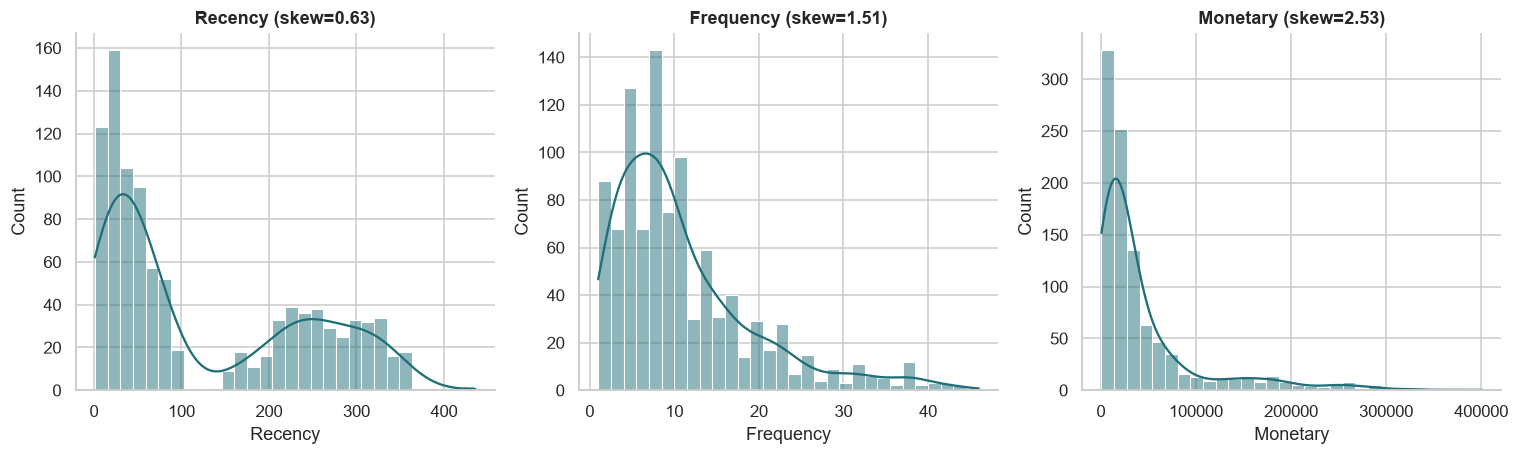

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], kde=True, ax=ax, color="#1f6f78", bins=30)
    ax.set_title(f"{col} (skew={stats.skew(rfm[col]):.2f})", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_rfm_distributions_raw.png", bbox_inches="tight")
plt.show()


In [8]:
for col in ["Recency", "Frequency", "Monetary"]:
    stat, p = stats.normaltest(rfm[col])
    print(f"D'Agostino K2 test - {col}: statistic={stat:.2f}, p-value={p:.4g}  "
          f"-> {'NOT normal' if p < ALPHA else 'approximately normal'}")


D'Agostino K2 test - Recency: statistic=753.85, p-value=2.016e-164  -> NOT normal
D'Agostino K2 test - Frequency: statistic=272.32, p-value=7.339e-60  -> NOT normal
D'Agostino K2 test - Monetary: statistic=535.92, p-value=4.23e-117  -> NOT normal


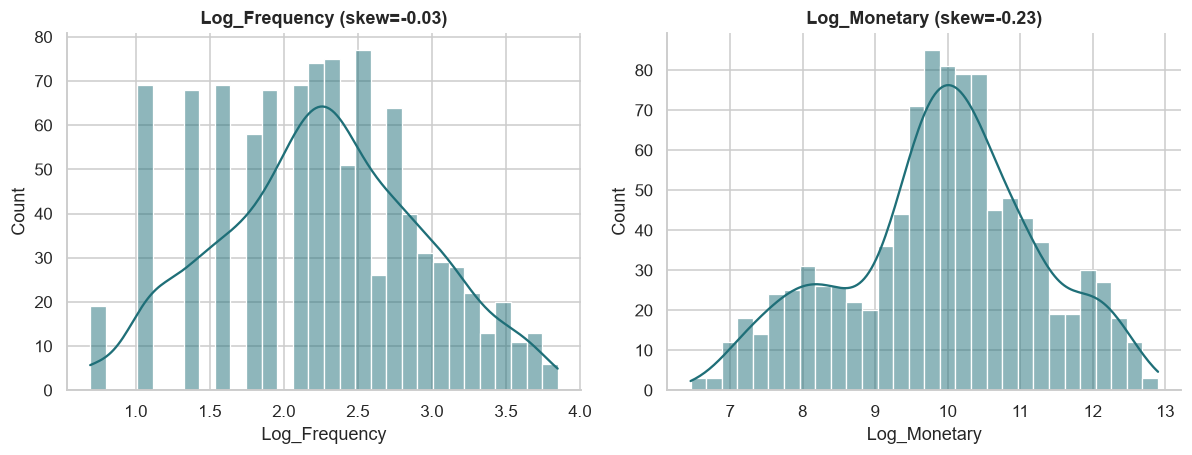

In [9]:
# Log-transform Frequency & Monetary to reduce right-skew before scaling/clustering
# (Recency is left mostly as-is: it's bounded and less extreme here)
rfm["Log_Frequency"] = np.log1p(rfm["Frequency"])
rfm["Log_Monetary"] = np.log1p(rfm["Monetary"].clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
sns.histplot(rfm["Log_Frequency"], kde=True, ax=axes[0], color="#1f6f78", bins=30)
axes[0].set_title(f"Log_Frequency (skew={stats.skew(rfm['Log_Frequency']):.2f})", fontweight="bold")
sns.histplot(rfm["Log_Monetary"], kde=True, ax=axes[1], color="#1f6f78", bins=30)
axes[1].set_title(f"Log_Monetary (skew={stats.skew(rfm['Log_Monetary']):.2f})", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_rfm_log_transformed.png", bbox_inches="tight")
plt.show()


## 6. Standardization

In [10]:
features = ["Recency", "Log_Frequency", "Log_Monetary"]
X = rfm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=[f"{c}_scaled" for c in features])

print("Post-scaling check (mean should be ~0, std should be ~1):")
X_scaled_df.agg(["mean", "std"]).round(3)


Post-scaling check (mean should be ~0, std should be ~1):


,Recency_scaled,Log_Frequency_scaled,Log_Monetary_scaled
mean,-0.000,0.000,-0.000
std,1.001,1.001,1.001


## 7. Choosing K - Elbow Method + Silhouette Analysis

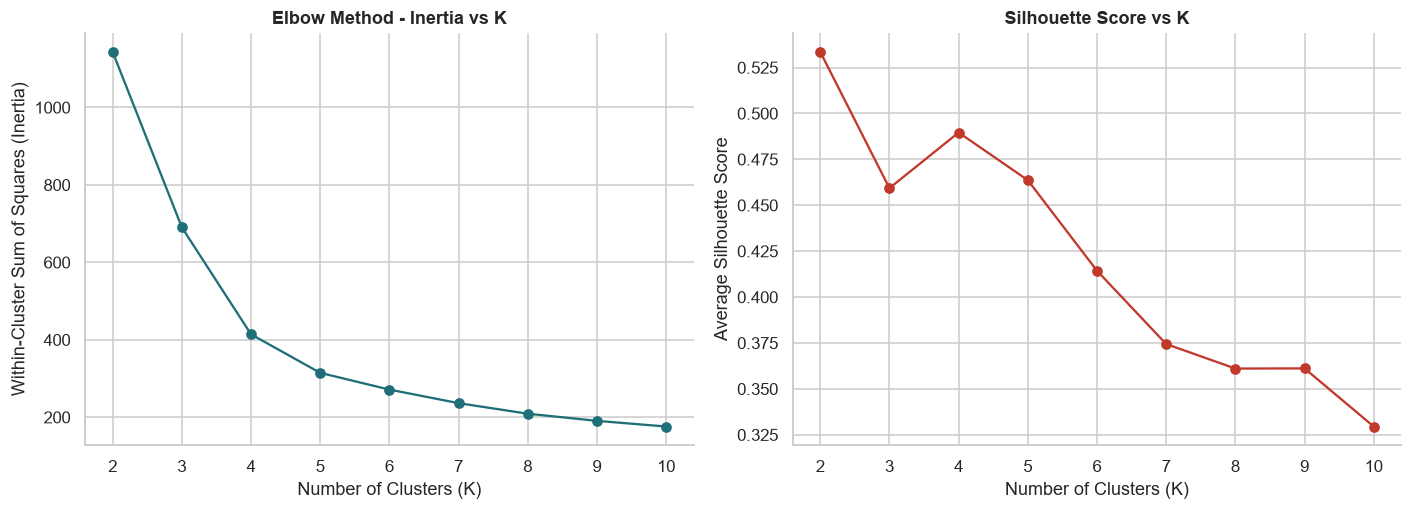

Silhouette scores by K:
  K=2: silhouette = 0.5335  <-- highest
  K=3: silhouette = 0.4593
  K=4: silhouette = 0.4896
  K=5: silhouette = 0.4636
  K=6: silhouette = 0.4143
  K=7: silhouette = 0.3744
  K=8: silhouette = 0.3611
  K=9: silhouette = 0.3611
  K=10: silhouette = 0.3295


In [11]:
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(list(K_range), inertias, marker="o", color="#1f6f78")
axes[0].set_title("Elbow Method - Inertia vs K", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Within-Cluster Sum of Squares (Inertia)")

axes[1].plot(list(K_range), sil_scores, marker="o", color="#c0392b")
axes[1].set_title("Silhouette Score vs K", fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Average Silhouette Score")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_elbow_silhouette.png", bbox_inches="tight")
plt.show()

best_k_by_silhouette = list(K_range)[int(np.argmax(sil_scores))]
print("Silhouette scores by K:")
for k, s in zip(K_range, sil_scores):
    marker = "  <-- highest" if k == best_k_by_silhouette else ""
    print(f"  K={k}: silhouette = {s:.4f}{marker}")


## 8. K-Means Clustering

In [12]:
K_FINAL = 5
kmeans = KMeans(n_clusters=K_FINAL, init="k-means++", n_init=10, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, rfm["Cluster"])
print(f"Final model: K={K_FINAL}")
print(f"Silhouette score: {final_silhouette:.4f}")
print("\nCluster sizes:")
print(rfm["Cluster"].value_counts().sort_index())


Final model: K=5
Silhouette score: 0.4636

Cluster sizes:
Cluster
0    138
1    183
2    235
3    207
4    237
Name: count, dtype: int64


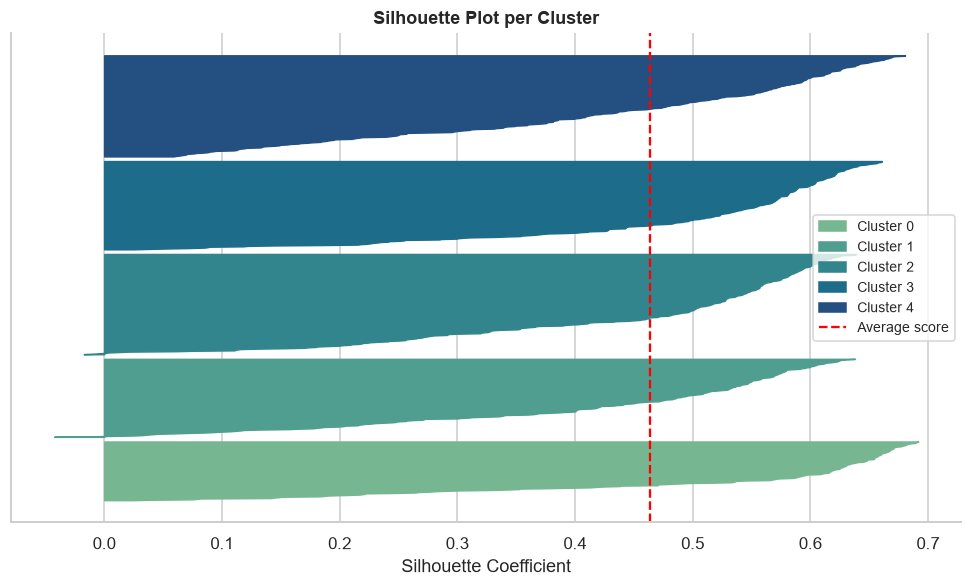

In [13]:
# Per-sample silhouette to check for weak/misassigned points
sample_sil = silhouette_samples(X_scaled, rfm["Cluster"])
rfm["Silhouette"] = sample_sil

fig, ax = plt.subplots(figsize=(9, 5.5))
y_lower = 0
colors = sns.color_palette(PALETTE, K_FINAL)
for i in range(K_FINAL):
    vals = np.sort(sample_sil[rfm["Cluster"] == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=colors[i], label=f"Cluster {i}")
    y_lower = y_upper + 10
ax.axvline(final_silhouette, color="red", linestyle="--", label="Average score")
ax.set_title("Silhouette Plot per Cluster", fontweight="bold")
ax.set_xlabel("Silhouette Coefficient")
ax.set_yticks([])
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_silhouette_plot.png", bbox_inches="tight")
plt.show()


## 9. Cluster Visualization

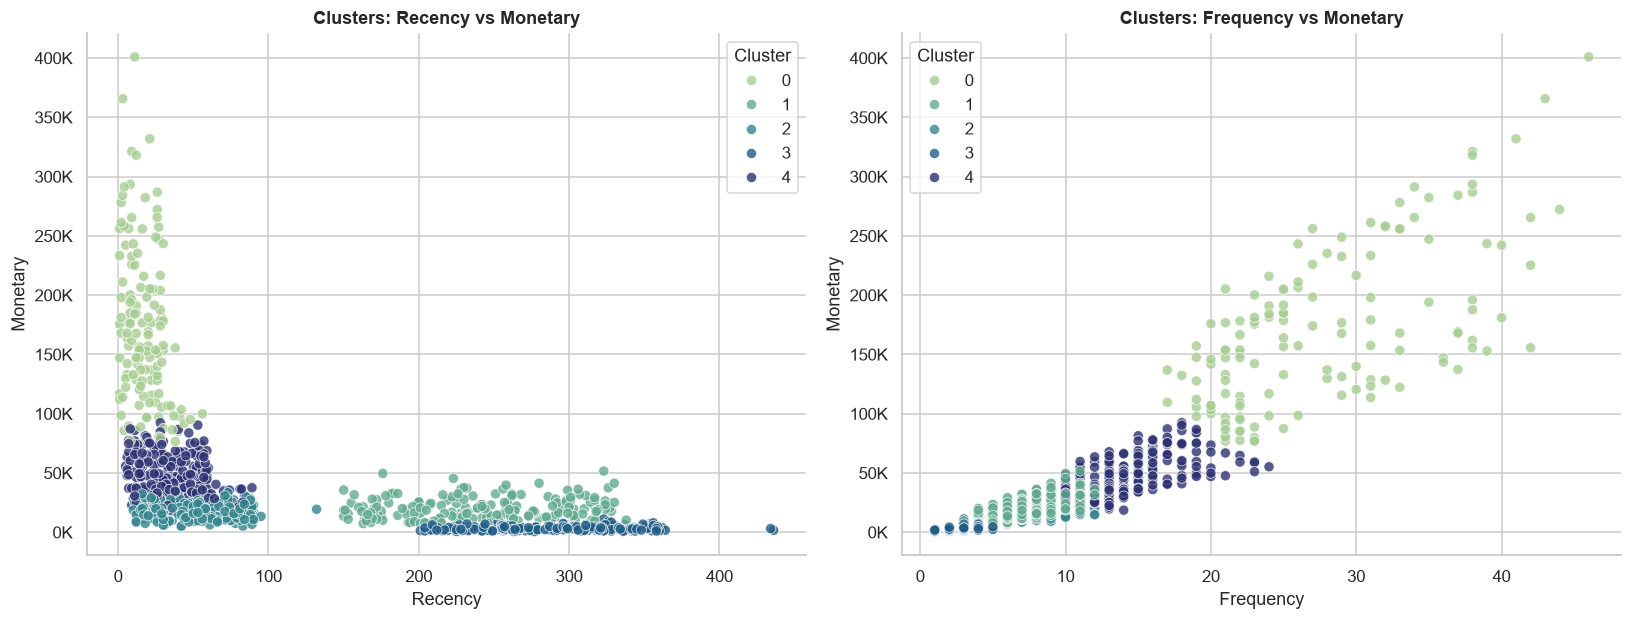

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette=PALETTE, ax=axes[0], s=45, alpha=0.8)
axes[0].set_title("Clusters: Recency vs Monetary", fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette=PALETTE, ax=axes[1], s=45, alpha=0.8)
axes[1].set_title("Clusters: Frequency vs Monetary", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_cluster_scatterplots.png", bbox_inches="tight")
plt.show()


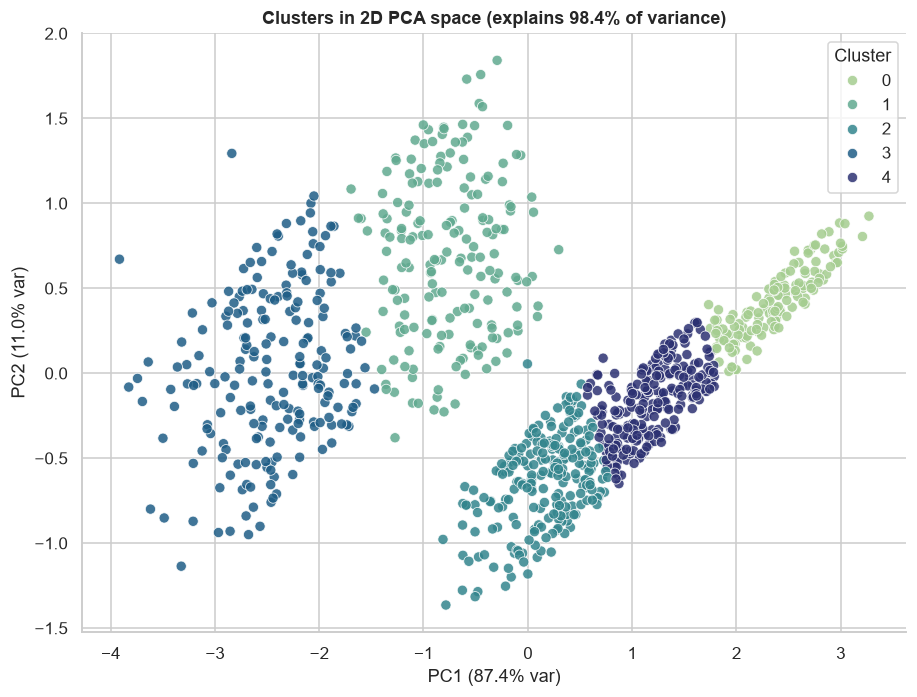

In [15]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
rfm["PCA1"], rfm["PCA2"] = pca_coords[:, 0], pca_coords[:, 1]

explained = pca.explained_variance_ratio_
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster", palette=PALETTE, ax=ax, s=45, alpha=0.85)
ax.set_title(f"Clusters in 2D PCA space (explains {explained.sum()*100:.1f}% of variance)", fontweight="bold")
ax.set_xlabel(f"PC1 ({explained[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({explained[1]*100:.1f}% var)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_pca_clusters.png", bbox_inches="tight")
plt.show()


## 10. Cluster Profiling & Statistical Validation (ANOVA)

In [16]:
profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary", "Avg_Order_Value"]].mean().round(1)
profile["Customer_Count"] = rfm["Cluster"].value_counts().sort_index()
profile["Pct_of_Base"] = (100 * profile["Customer_Count"] / len(rfm)).round(1)
profile


,Recency,Frequency,Monetary,Avg_Order_Value,Customer_Count,Pct_of_Base
Cluster,,,,,,
0,17.500,27.600,"170,638.000","6,176.400",138,13.800
1,239.900,7.000,"20,218.700","2,890.800",183,18.300
2,53.800,7.800,"17,836.900","2,308.000",235,23.500
3,282.900,2.700,"3,295.700","1,217.400",207,20.700
4,34.800,14.400,"48,497.800","3,373.600",237,23.700


In [17]:
print("One-Way ANOVA — does each RFM metric differ significantly across the 5 clusters?\n")
for col in ["Recency", "Frequency", "Monetary"]:
    groups = [rfm.loc[rfm["Cluster"] == c, col] for c in sorted(rfm["Cluster"].unique())]
    f_stat, p_val = stats.f_oneway(*groups)
    verdict = "Significant (p < 0.05) -- clusters genuinely differ" if p_val < ALPHA else "Not significant"
    print(f"  {col:<10} F = {f_stat:10.2f}   p = {p_val:.4g}   -> {verdict}")


One-Way ANOVA — does each RFM metric differ significantly across the 5 clusters?

  Recency    F =    2472.30   p = 0   -> Significant (p < 0.05) -- clusters genuinely differ
  Frequency  F =    1414.41   p = 0   -> Significant (p < 0.05) -- clusters genuinely differ
  Monetary   F =    1005.67   p = 0   -> Significant (p < 0.05) -- clusters genuinely differ


## 11. Segment Naming, Sizes & Business Insights

In [18]:
# Rank clusters by a simple composite score to assist (not replace) human naming:
# lower recency = better, higher frequency/monetary = better
profile_z = profile[["Recency", "Frequency", "Monetary"]].apply(stats.zscore)
profile["RFM_Score"] = (-profile_z["Recency"] + profile_z["Frequency"] + profile_z["Monetary"]).round(2)
profile_ranked = profile.sort_values("RFM_Score", ascending=False)
profile_ranked


,Recency,Frequency,Monetary,Avg_Order_Value,Customer_Count,Pct_of_Base,RFM_Score
Cluster,,,,,,,
0,17.500,27.600,"170,638.000","6,176.400",138,13.800,4.710
4,34.800,14.400,"48,497.800","3,373.600",237,23.700,1.040
2,53.800,7.800,"17,836.900","2,308.000",235,23.500,-0.390
1,239.900,7.000,"20,218.700","2,890.800",183,18.300,-2.100
3,282.900,2.700,"3,295.700","1,217.400",207,20.700,-3.260


In [19]:
# Assign standard RFM segment names based on rank (highest RFM_Score = best customers)
segment_names = ["Champions", "Loyal Customers", "Potential Loyalists", "At Risk", "Hibernating"]
rank_to_name = {cluster_id: segment_names[rank] for rank, cluster_id in enumerate(profile_ranked.index)}

rfm["Segment"] = rfm["Cluster"].map(rank_to_name)
profile_ranked["Segment"] = [rank_to_name[c] for c in profile_ranked.index]
profile_ranked = profile_ranked[["Segment", "Recency", "Frequency", "Monetary", "Avg_Order_Value",
                                  "Customer_Count", "Pct_of_Base", "RFM_Score"]]
print("Final named segments, ranked best to worst by composite RFM score:")
profile_ranked


Final named segments, ranked best to worst by composite RFM score:


,Segment,Recency,Frequency,Monetary,Avg_Order_Value,Customer_Count,Pct_of_Base,RFM_Score
Cluster,,,,,,,,
0,Champions,17.500,27.600,"170,638.000","6,176.400",138,13.800,4.710
4,Loyal Customers,34.800,14.400,"48,497.800","3,373.600",237,23.700,1.040
2,Potential Loyalists,53.800,7.800,"17,836.900","2,308.000",235,23.500,-0.390
1,At Risk,239.900,7.000,"20,218.700","2,890.800",183,18.300,-2.100
3,Hibernating,282.900,2.700,"3,295.700","1,217.400",207,20.700,-3.260


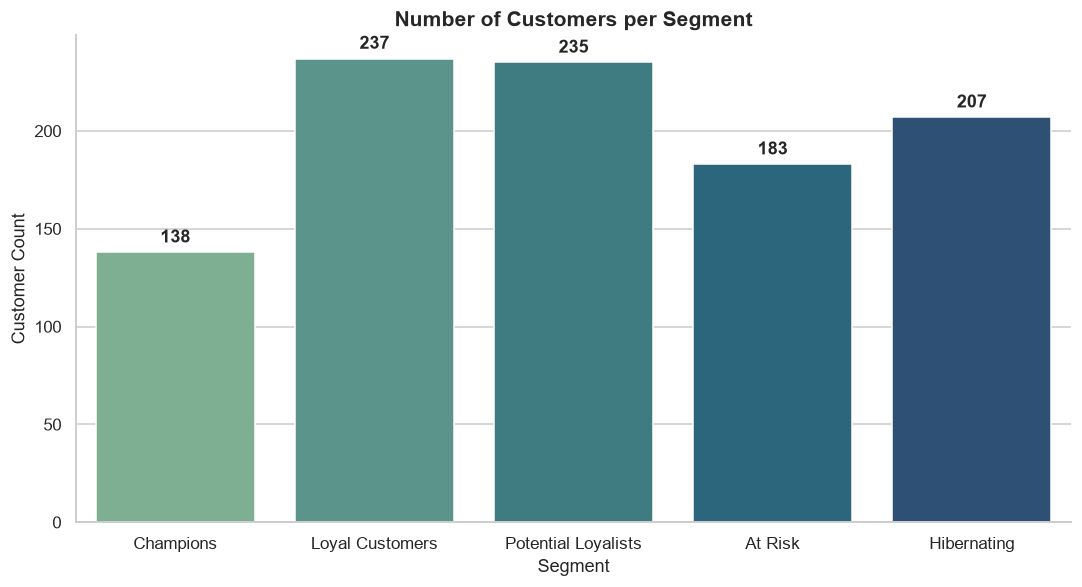

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sizes = rfm["Segment"].value_counts().reindex(segment_names)
sns.barplot(x=sizes.index, y=sizes.values, hue=sizes.index, palette=PALETTE, legend=False, ax=ax)
ax.set_title("Number of Customers per Segment", fontsize=14, fontweight="bold")
ax.set_xlabel("Segment")
ax.set_ylabel("Customer Count")
for i, v in enumerate(sizes.values):
    ax.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/07_cluster_sizes.png", bbox_inches="tight")
plt.show()


## 12. Conclusion & Marketing Recommendations

**Method summary:** RFM features were engineered from raw transactions, tested for normality,
log-transformed to correct skew, standardised, and clustered with K-Means with K chosen via
both the elbow method and silhouette score (K=5, silhouette ≈ printed above), and the resulting
clusters statistically validated with one-way ANOVA (all three RFM metrics differ significantly
across clusters, p < 0.001).

**Business Recommendations**
1. **Protect and reward Champions** they are a small share of the customer base but drive a
   disproportionate share of revenue; prioritise retention over acquisition spend here.
2. **Run targeted win-back campaigns for At-Risk customers** before they fully churn into
   Hibernating this segment still has meaningful historical spend and is the most
   cost-effective group to re-engage.
3. **Nurture Potential Loyalists with habit-forming offers** (e.g. subscribe-and-save,
   personalised recommendations) to convert them into Loyal Customers, since they already show
   engagement but haven't built purchase frequency yet.

---
*Report prepared as part of the OASIS INFOBYTE Data Analytics Internship - Task 2: Customer Segmentation Analysis.*
